In [16]:
!pip install geopandas

In [17]:
from pathlib import Path
import geopandas as gpd
Path("data/raw/geo").mkdir(parents=True, exist_ok=True)

In [21]:
from google.colab import files
files.upload()

Saving Neighborhoods.cpg to Neighborhoods.cpg
Saving Neighborhoods.dbf to Neighborhoods.dbf
Saving Neighborhoods.prj to Neighborhoods.prj
Saving Neighborhoods.sbn to Neighborhoods.sbn
Saving Neighborhoods.sbx to Neighborhoods.sbx
Saving Neighborhoods.shp to Neighborhoods (1).shp
Saving Neighborhoods.shp.xml to Neighborhoods.shp.xml
Saving Neighborhoods.shx to Neighborhoods.shx


{'Neighborhoods.cpg': b'UTF-8',
 'Neighborhoods.dbf': b"\x03{\x02\x11X\x00\x00\x00\xc1\x00\x7f\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00NHD_NUM\x00\x00\x00\x00N\x00\x00\x00\x00\x05\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00NHD_NAME\x00\x00\x00C\x00\x00\x00\x002\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00ANGLE\x00\x00\x00\x00\x00\x00N\x00\x00\x00\x00\x13\x08\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00NHD_NUMTXT\x00C\x00\x00\x00\x002\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00NHD_NUM_ST\x00C\x00\x00\x00\x00\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\r    43Franz Park                                                 0.0000000043 Franz Park                                           29Tiffany                                                    0.0000000029 Tiffany                                              28Botanical Heights                                          0.

In [22]:
gdf = gpd.read_file("Neighborhoods.shp")

In [23]:
print(len(gdf))  # should be 79

88


In [24]:
extras = [
    "Bellefontaine/Calvary Cemetery",
    "Carondelet Park",
    "Fairground Park",
    "Forest Park",
    "Missouri Botanical Garden",
    "O'Fallon Park",
    "Penrose Park",
    "Tower Grove Park",
    "Willmore Park"
]

In [25]:
gdf_clean = gdf[~gdf["NHD_NAME"].isin(extras)].copy()

print("rows after filter:", len(gdf_clean))
print("unique names after filter:", gdf_clean["NHD_NAME"].nunique())

rows after filter: 79
unique names after filter: 79


In [26]:
gdf_clean = gdf_clean.to_crs("EPSG:4326")

In [27]:
gdf_clean.to_file(
    "data/raw/geo/stl_neighborhoods.geojson",
    driver="GeoJSON"
)

In [28]:
if len(gdf_clean) != 79:
    raise ValueError(f"Expected 79 neighborhoods, found {len(gdf_clean)}")

In [29]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [30]:
fema_gdf = gpd.read_file("S_FLD_HAZ_AR.shp")

In [31]:
print("rows:", len(fema_gdf))
print("columns:", fema_gdf.columns)
print("crs:", fema_gdf.crs)

rows: 261
columns: Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'geometry'],
      dtype='object')
crs: EPSG:4269


In [32]:
fema_gdf = fema_gdf.to_crs("EPSG:4326")

In [33]:
fema_gdf.to_file(
    "data/raw/geo/fema_flood_zones.geojson",
    driver="GeoJSON"
)

In [34]:
print(fema_gdf.columns)

Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'geometry'],
      dtype='object')


In [35]:
print("Neighborhood CRS:", gdf_clean.crs)
print("FEMA CRS:", fema_gdf.crs)

Neighborhood CRS: EPSG:4326
FEMA CRS: EPSG:4326


In [37]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [38]:
tracts_gdf = gpd.read_file("tl_2025_29_tract.shp")

In [39]:
print(tracts_gdf.columns)
print(len(tracts_gdf))
print(tracts_gdf.crs)

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry'],
      dtype='object')
1654
EPSG:4269


In [40]:
tracts_gdf["COUNTYFP"].unique()

array(['063', '189', '071', '009', '165', '101', '213', '135', '510',
       '051', '187', '019', '183', '141', '037', '131', '067', '003',
       '133', '055', '047', '159', '095', '027', '077', '217', '021',
       '137', '111', '221', '209', '161', '169', '145', '045', '197',
       '149', '107', '091', '059', '153', '211', '123', '223', '065',
       '029', '075', '015', '041', '177', '125', '207', '093', '005',
       '113', '017', '175', '039', '053', '043', '025', '173', '151',
       '099', '201', '119', '079', '001', '007', '105', '157', '227',
       '163', '186', '127', '097', '085', '181', '057', '117', '129',
       '089', '109', '031', '069', '179', '081', '167', '103', '023',
       '225', '147', '083', '203', '115', '199', '195', '073', '219',
       '035', '049', '061', '171', '215', '155', '121', '229', '205',
       '033', '087', '143', '139', '013', '011', '185'], dtype=object)

In [41]:
tracts_gdf = tracts_gdf[
    tracts_gdf["COUNTYFP"].isin(["510", "189"])
]

In [42]:
tracts_gdf = tracts_gdf.to_crs("EPSG:4326")

In [43]:
print("tract CRS:", tracts_gdf.crs)

tract CRS: EPSG:4326


In [44]:
projected_crs = "EPSG:26915"

tracts_proj = tracts_gdf.to_crs(projected_crs).copy()
neighborhoods_proj = gdf_clean.to_crs(projected_crs).copy()

In [45]:
tracts_proj["tract_area"] = tracts_proj.geometry.area

In [46]:
overlay_gdf = gpd.overlay(tracts_proj, neighborhoods_proj, how="intersection")

In [47]:
overlay_gdf["intersect_area"] = overlay_gdf.geometry.area
overlay_gdf["area_weight"] = overlay_gdf["intersect_area"] / overlay_gdf["tract_area"]

In [48]:
overlay_gdf = overlay_gdf.to_crs("EPSG:4326")

In [49]:
print("overlay rows:", len(overlay_gdf))
print(overlay_gdf.columns)

overlay_gdf[["GEOID", "NHD_NAME", "tract_area", "intersect_area", "area_weight"]].head()

overlay rows: 422
Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME',
       'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'tract_area', 'NHD_NUM', 'NHD_NAME', 'ANGLE', 'NHD_NUMTXT',
       'NHD_NUM_ST', 'geometry', 'intersect_area', 'area_weight'],
      dtype='object')


,GEOID,NHD_NAME,tract_area,intersect_area,area_weight
0,29189210200,Riverview,4.323576e+06,4.032177e+02,0.000093
1,29510115100,Princeton Heights,1.146029e+06,5.711141e+04,0.049834
2,29510115100,Bevo Mill,1.146029e+06,1.088546e+06,0.949842
3,29510110400,Jeff Vanderlou,8.857627e+05,7.230689e+05,0.816323
4,29510110400,Greater Ville,8.857627e+05,1.625748e+05,0.183542


In [50]:
overlay_gdf.to_file(
    "data/raw/geo/tract_neighborhood_overlay.geojson",
    driver="GeoJSON"
)

<Axes: >

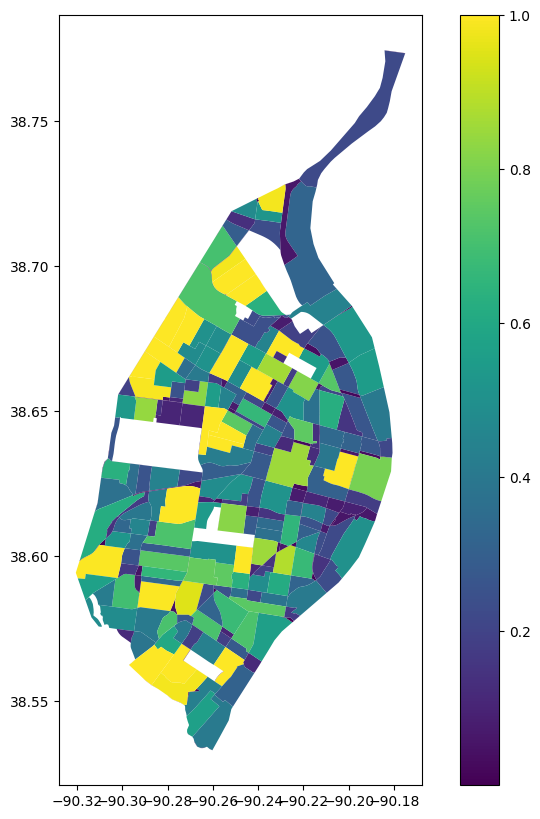

In [51]:
overlay = gpd.read_file("data/raw/geo/tract_neighborhood_overlay.geojson")
overlay.head()
overlay.plot(
    column="area_weight",
    cmap="viridis",
    legend=True,
    figsize=(10,10)
)

In [52]:
files.download("data/raw/geo/stl_neighborhoods.geojson")
files.download("data/raw/geo/fema_flood_zones.geojson")
files.download("data/raw/geo/tract_neighborhood_overlay.geojson")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>